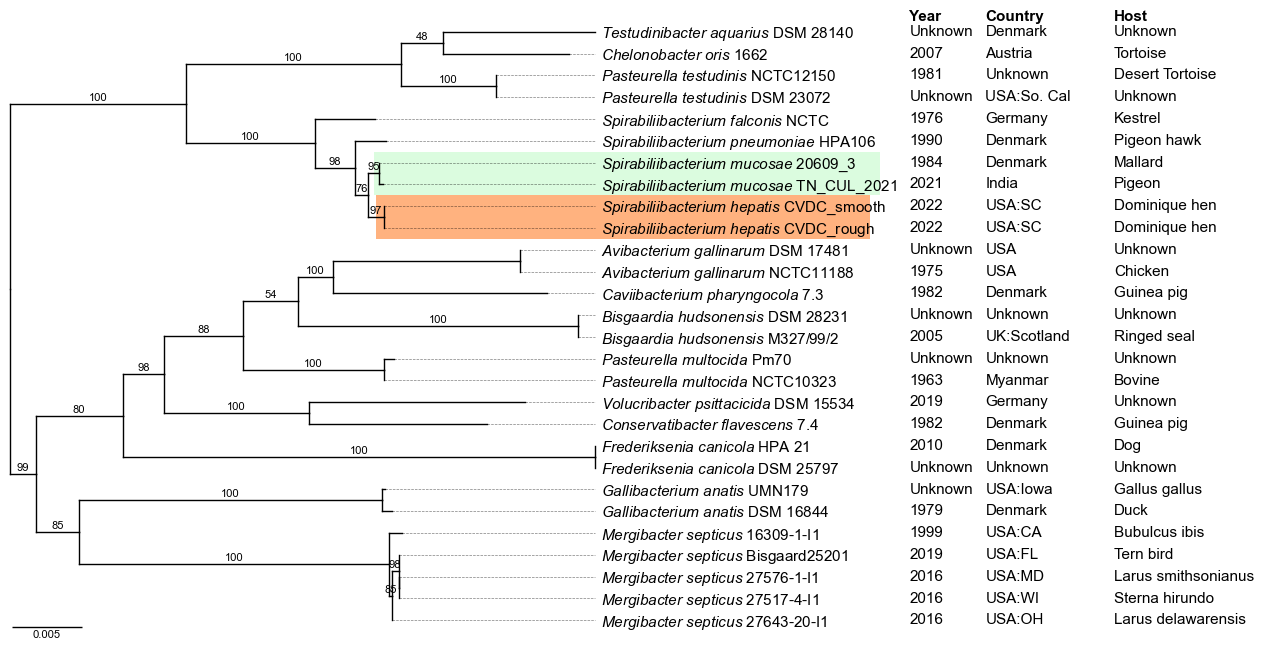

In [ ]:
import matplotlib.pyplot as plt
from Bio import Phylo
from phytreeviz import TreeViz
from matplotlib.patches import Patch

# 1. DATA SETUP
name_mapping = {
    "GCF_000772535.1": ["Chelonobacter oris 1662", "2007", "Austria", "Tortoise"],
    "GCF_000209675.1": ["Gallibacterium anatis UMN179", "Unknown", "USA:Iowa", "Gallus gallus"],
    "GCF_000379785.1": ["Gallibacterium anatis DSM 16844", "1979", "Denmark", "Duck"],
    "GCF_900176075.1": ["Pasteurella testudinis DSM 23072", "Unknown", "USA:So. Cal", "Unknown"],
    "GCF_900454705.1": ["Pasteurella testudinis NCTC12150", "1981", "Unknown", "Desert Tortoise"],
    "GCF_004342725.1": ["Testudinibacter aquarius DSM 28140", "Unknown", "Denmark", "Unknown"],
    "GCF_000006825.1": ["Pasteurella multocida Pm70", "Unknown", "Unknown", "Unknown"],
    "GCF_900638665.1": ["Pasteurella multocida NCTC10323", "1963", "Myanmar", "Bovine"],
    "GCF_004362535.1": ["Avibacterium gallinarum DSM 17481", "Unknown", "USA", "Unknown"],
    "GCF_900454485.1": ["Avibacterium gallinarum NCTC11188", "1975", "USA", "Chicken"],
    "GCF_013377195.1": ["Bisgaardia hudsonensis M327/99/2", "2005", "UK:Scotland", "Ringed seal"],
    "GCF_004345785.1": ["Bisgaardia hudsonensis DSM 28231", "Unknown", "Unknown", "Unknown"],
    "GCF_003265205.1": ["Mergibacter septicus 16309-1-I1", "1999", "USA:CA", "Bubulcus ibis"],
    "GCF_006770465.1": ["Mergibacter septicus 27576-1-I1", "2016", "USA:MD", "Larus smithsonianus"],
    "GCF_006770445.1": ["Mergibacter septicus 27643-20-I1", "2016", "USA:OH", "Larus delawarensis"],
    "GCF_024371585.1": ["Mergibacter septicus Bisgaard25201", "2019", "USA:FL", "Tern bird"],
    "GCF_003265225.1": ["Mergibacter septicus 27517-4-I1", "2016", "USA:WI", "Sterna hirundo"],
    "GCF_004339025.1": ["Volucribacter psittacicida DSM 15534", "2019", "Germany", "Unknown"],
    "GCF_003814575.1": ["Frederiksenia canicola DSM 25797", "Unknown", "Unknown", "Unknown"],
    "GCF_011455495.1": ["Frederiksenia canicola HPA 21", "2010", "Denmark", "Dog"],
    "GCF_002795405.1": ["Caviibacterium pharyngocola 7.3", "1982", "Denmark", "Guinea pig"],
    "GCF_002795425.1": ["Conservatibacter flavescens 7.4", "1982", "Denmark", "Guinea pig"],
    "rough1_genome_nextpolish": ["Spirabiliibacterium hepatis CVDC_rough", "2022", "USA:SC", "Dominique hen"],
    "smooth1_genome_nextpolish": ["Spirabiliibacterium hepatis CVDC_smooth", "2022", "USA:SC", "Dominique hen"],
    "ref1": ["Spirabiliibacterium mucosae 20609_3", "1984", "Denmark", "Mallard"],
    "ref2": ["Spirabiliibacterium pneumoniae HPA106", "1990", "Denmark", "Pigeon hawk"],
    "ref3": ["Spirabiliibacterium falconis NCTC", "1976", "Germany", "Kestrel"],
    "ref4": ["Spirabiliibacterium mucosae TN_CUL_2021", "2021", "India", "Pigeon"]
}

plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'mathtext.fontset': 'custom',
    'mathtext.it': 'Arial:italic',
    'mathtext.rm': 'Arial'
})

def italic_species(name):
    words = name.split()
    italic_part = r'\ '.join(words[:2])
    normal_part = ' '.join(words[2:])
    return r'$\it{' + italic_part + r'}$ ' + normal_part if normal_part else r'$\it{' + italic_part + r'}$'

# 2. TREE SETUP
tree = Phylo.read("polymorphisms_move.phy.treefile", "newick")
tree.root_at_midpoint()

metadata_lookup = {}
for leaf in tree.get_terminals():
    if leaf.name in name_mapping:
        data = name_mapping[leaf.name]
        formatted = italic_species(data[0])
        metadata_lookup[formatted] = data[1:]
        leaf.name = formatted

temp_tree = "formatted_tree.nwk"
Phylo.write(tree, temp_tree, "newick")

# 3. PLOT
tv = TreeViz(temp_tree, align_leaf_label=True, leaf_label_size=11)
tv.show_confidence(ypos="top", label_formatter=lambda v: f"{int(v)}")

cvdc_labels = [italic_species(name_mapping[k][0]) for k in ["rough1_genome_nextpolish", "smooth1_genome_nextpolish"]]
ref_labels = [italic_species(name_mapping[k][0]) for k in ["ref1","ref4"]]
tv.highlight(cvdc_labels, "#FF6600", alpha=0.5)
tv.highlight(ref_labels, "#B9FBC0", alpha=0.5)
tv.show_scale_bar()

fig = tv.plotfig()
ax = fig.gca()

# 4. FIXED ALIGNMENT LOGIC
# Force a draw so we can calculate physical text widths
fig.canvas.draw()

# Get the right-most edge of all species labels (in data coordinates)
max_x = 0
for t in ax.texts:
    if t.get_text() in metadata_lookup:
        # Get the bounding box of the text
        bbox = t.get_window_extent(fig.canvas.get_renderer())
        # Convert pixels back to data coordinates
        extent = ax.transData.inverted().transform(bbox)
        max_x = max(max_x, extent[1][0])

# Place columns with a fixed buffer after the longest label
x_range = ax.get_xlim()[1] - ax.get_xlim()[0]
col_year = max_x + (x_range * 0.05)
col_country = max_x + (x_range * 0.18)
col_host = max_x + (x_range * 0.40)

# Add Column Headers
top_y = len(tree.get_terminals()) + 0.5
ax.text(col_year, top_y, "Year", fontweight='bold', ha='left')
ax.text(col_country, top_y, "Country", fontweight='bold', ha='left')
ax.text(col_host, top_y, "Host", fontweight='bold', ha='left')

# Align metadata
for t in ax.texts:
    label = t.get_text()
    if label in metadata_lookup:
        year, country, host = metadata_lookup[label]
        y_pos = t.get_position()[1]
        
        ax.text(col_year, y_pos, year, va='center', ha='left')
        ax.text(col_country, y_pos, country, va='center', ha='left')
        ax.text(col_host, y_pos, host, va='center', ha='left')

# 5. LEGEND
# legend_elements = [
#     Patch(facecolor='#FF6600', label='CVDC Isolates', alpha=1),
#     Patch(facecolor='#B9FBC0', label='$\it{Spirabiliibacterium}$ Clade', alpha=1)
# ]
# ax.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(0, 1.1), frameon=False, ncol=2)

fig.set_size_inches(13, 8)
plt.subplots_adjust(right=0.5, top=0.9, left=0.05)
fig.savefig("phylogenetic_tree_arial_v4.jpg", dpi=600, bbox_inches='tight')
# Save as TIFF with LZW compression
fig.savefig(
    "JVDI_Figure1.tif", 
    dpi=700, 
    bbox_inches='tight',
    format='tiff',
    pil_kwargs={"compression": "tiff_lzw"}
)
plt.show()